## Goal: run example object detection pipepline.

1. Capture example image again.

Camera opened: True
Frame captured: True
Frame shape: (480, 640, 3)


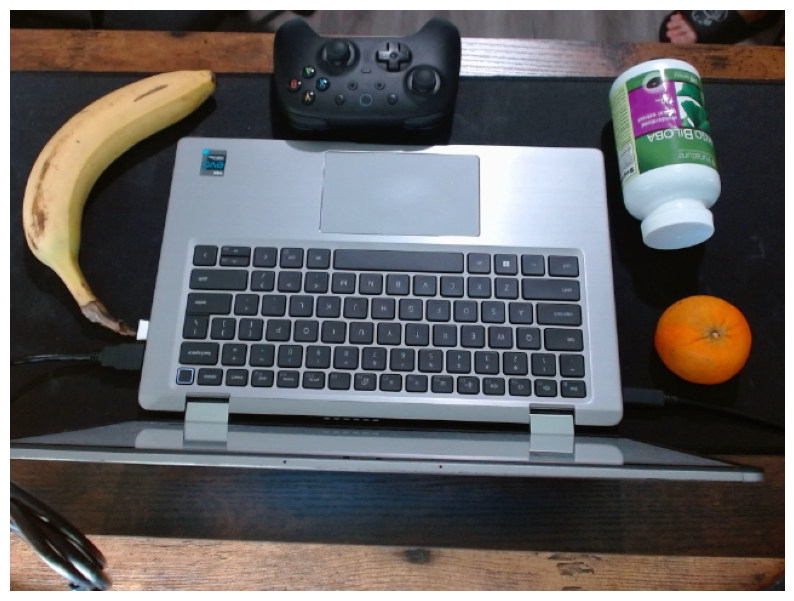

In [24]:
import cv2

cam = cv2.VideoCapture(0, cv2.CAP_V4L2)

print("Camera opened:", cam.isOpened())

time.sleep(2)

for i in range(30):
    ret, frame = cam.read()

cam.release()

print("Frame captured:", ret)
print("Frame shape:", frame.shape if ret else None)

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 8))
    plt.imshow(frame_rgb)
    plt.axis("off")
    plt.show()

2. Load YOLO object detection library

In [25]:
import ultralytics
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

try:
    print("Ultralytics version is: ", ultralytics.__version__)
except Exception as e:
    print("An unexpected error occured:", e)

print("YOLO model loaded successfully") # system won't print if YOLO model does not load

Ultralytics version is:  8.4.51
YOLO model loaded successfully


3. Enable object detection on captured image

In [26]:

results = model(frame)

result_img = results[0].plot()
result_img_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)



0: 480x640 1 person, 1 bottle, 1 banana, 1 orange, 1 remote, 30.2ms
Speed: 2.6ms preprocess, 30.2ms inference, 4.6ms postprocess per image at shape (1, 3, 480, 640)


4. Print YOLO output

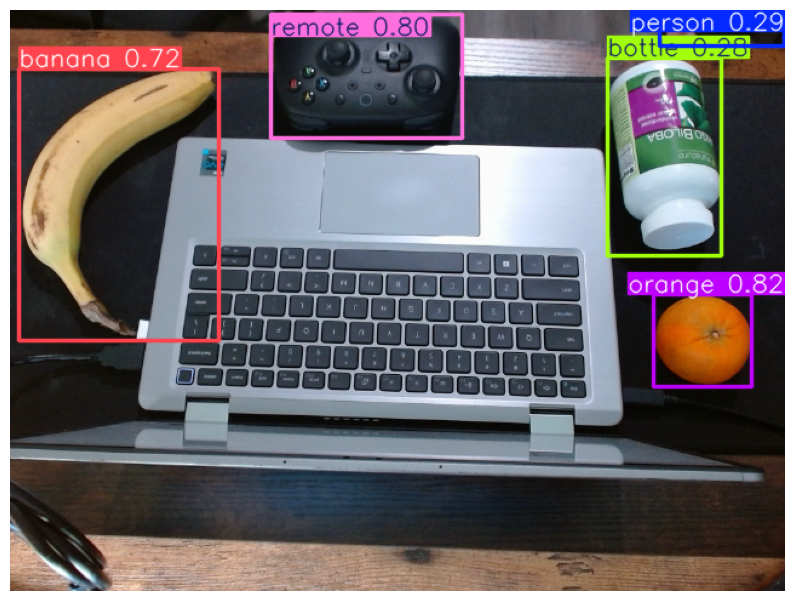

orange: 0.82
remote: 0.80
banana: 0.72
person: 0.29
bottle: 0.28


In [27]:
import matplotlib.pyplot as plt

# create a new Matplotlib window:
plt.figure(figsize=(10, 8))
# convert BGR from OpenCV to RGB, so Matplotlib can see the image:
plt.imshow(result_img_rgb) 
# hide x/y axis numbers around the image:
plt.axis("off")
# render the detection result:
plt.show()

for box in results[0].boxes:
    cls_id = int(box.cls[0]) # obj class ID
    conf = float(box.conf[0]) # obj confidence score
    label = model.names[cls_id] # convert ID to label

    print(f"{label}: {conf:.2f}")